In [1]:
# First import all the packages and dependencies that we use in our project .

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler,RobustScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet

In [3]:
## Load the dataset 

data=pd.read_csv("solarpowergeneration.csv")
data.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [4]:
## find te info of the data 

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [5]:
## checking Null and Duplicated Values 

In [6]:
data.isnull().sum().sum()

np.int64(1)

In [7]:
### the null values are less than 0.5% , remove null values .

data.dropna(inplace=True)
data.isnull().sum().sum()

np.int64(0)

In [8]:
data.duplicated().sum().sum()

np.int64(0)

In [9]:
### Describe te data , like find the mean, meadin , mode and standard deviation and varience of all coloumns 

data.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,0.503327,58.468996,24.957862,10.099486,1.987667,9.559609,73.505995,10.129154,30.017712,6982.182939
std,0.298069,6.842318,6.912203,4.837128,1.412220,1.380290,15.073974,7.261547,0.142006,10313.330078
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.232061,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.479241,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739559,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12725.000000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


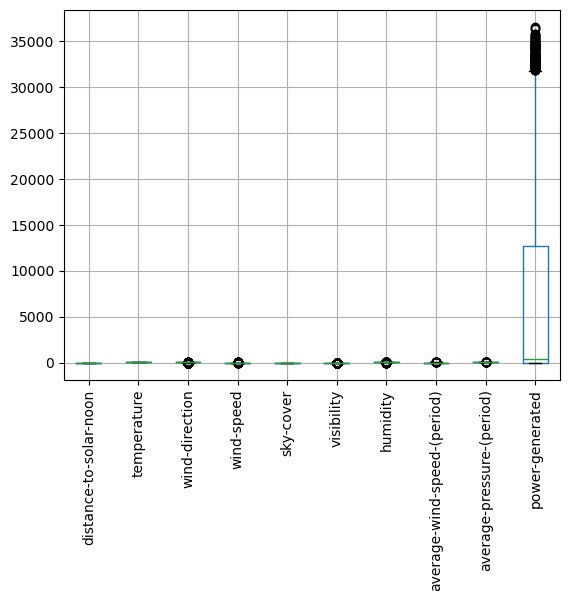

In [10]:
data.boxplot()
plt.xticks(rotation=90)
plt.show()

In [11]:
## we found tat there are outliers are presenrt in the features and the target , but our target features are real so we need not remove the outliers 
# in the target columns , so just remove or replace the poputliers values in the feature values .

In [12]:
# separate the target and features 

In [13]:
features=data.drop(columns=["power-generated"])
features.head()
target=data[["power-generated"]]
target.head()

,power-generated
0,0
1,0
2,5418
3,25477
4,30069


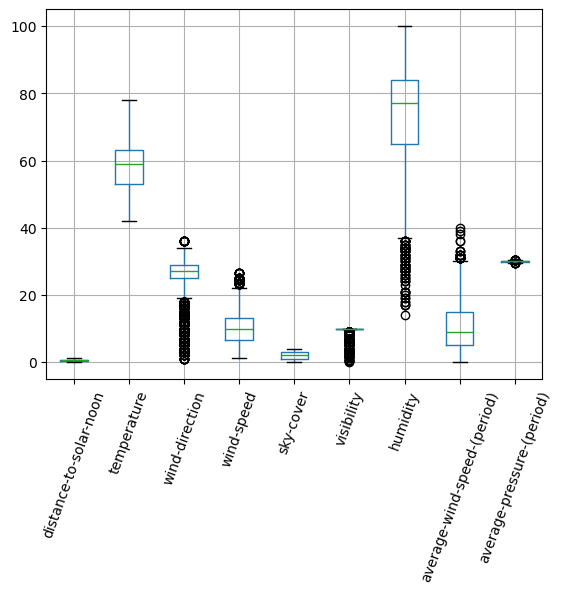

In [14]:
## find the outliers if any in features columns 

features.boxplot()
plt.xticks(rotation=70)
plt.show()

In [15]:
### replace the outliers values with the quartiles .
## outlier capping


In [16]:
#### outlier capping
def outlier_capping(features,column):
    Q1= features[column].quantile(0.25)
    Q3= features[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    features[column]= features[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in features.select_dtypes(['int','float']).columns:
    outlier_capping(features,col)

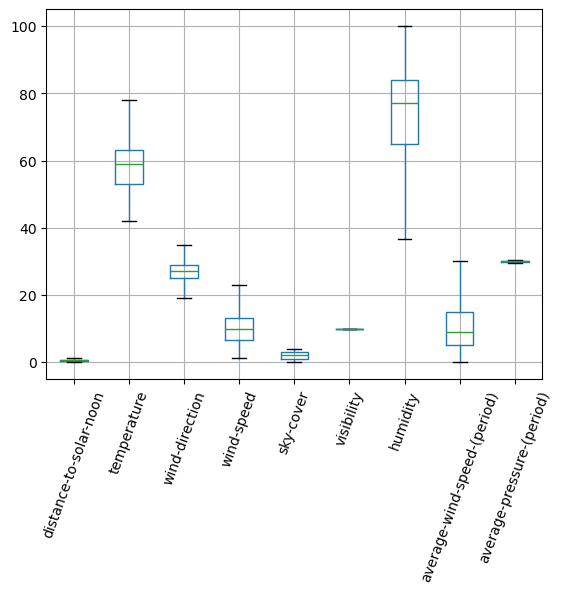

In [17]:
features.boxplot()
plt.xticks(rotation=70)
plt.show()

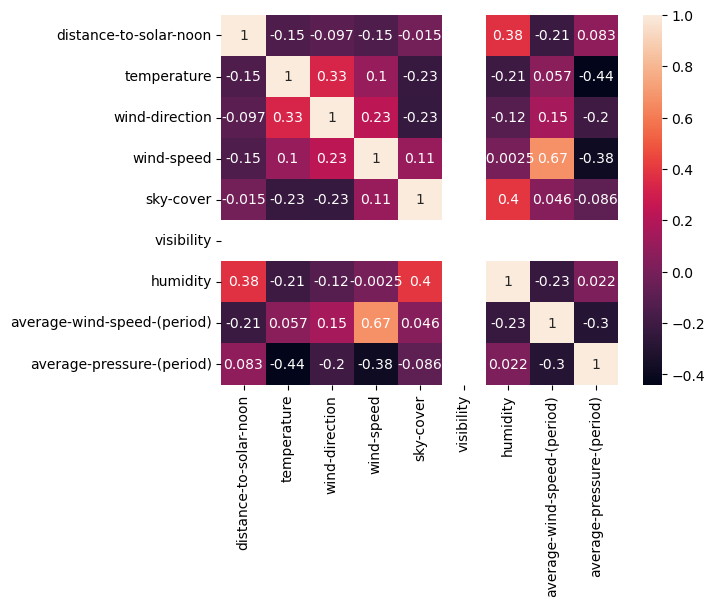

In [18]:
#### Feature Selection
### Correlation matrix
corr= features.corr()
sns.heatmap(corr,annot=True)
plt.show()

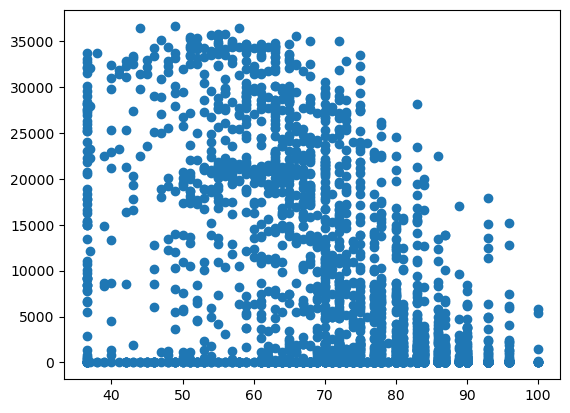

In [19]:
plt.scatter(features["humidity"], target)
plt.show()


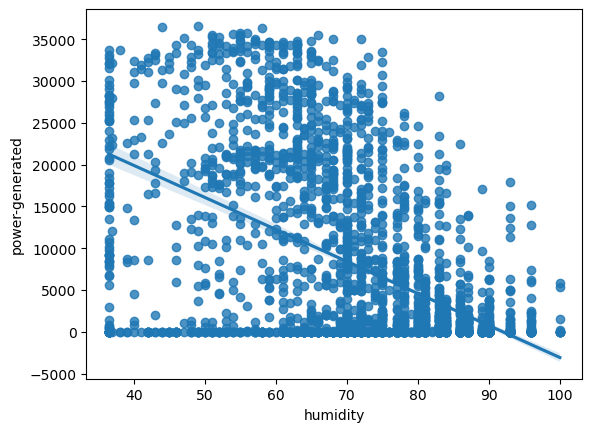

In [20]:
sns.regplot(x=features["humidity"], y=target, data=data)
plt.show()

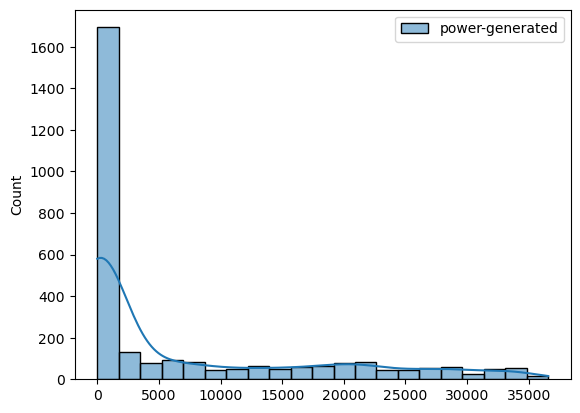

In [21]:
#Check if target is normally distributed.
sns.histplot(target, kde=True)
plt.show()

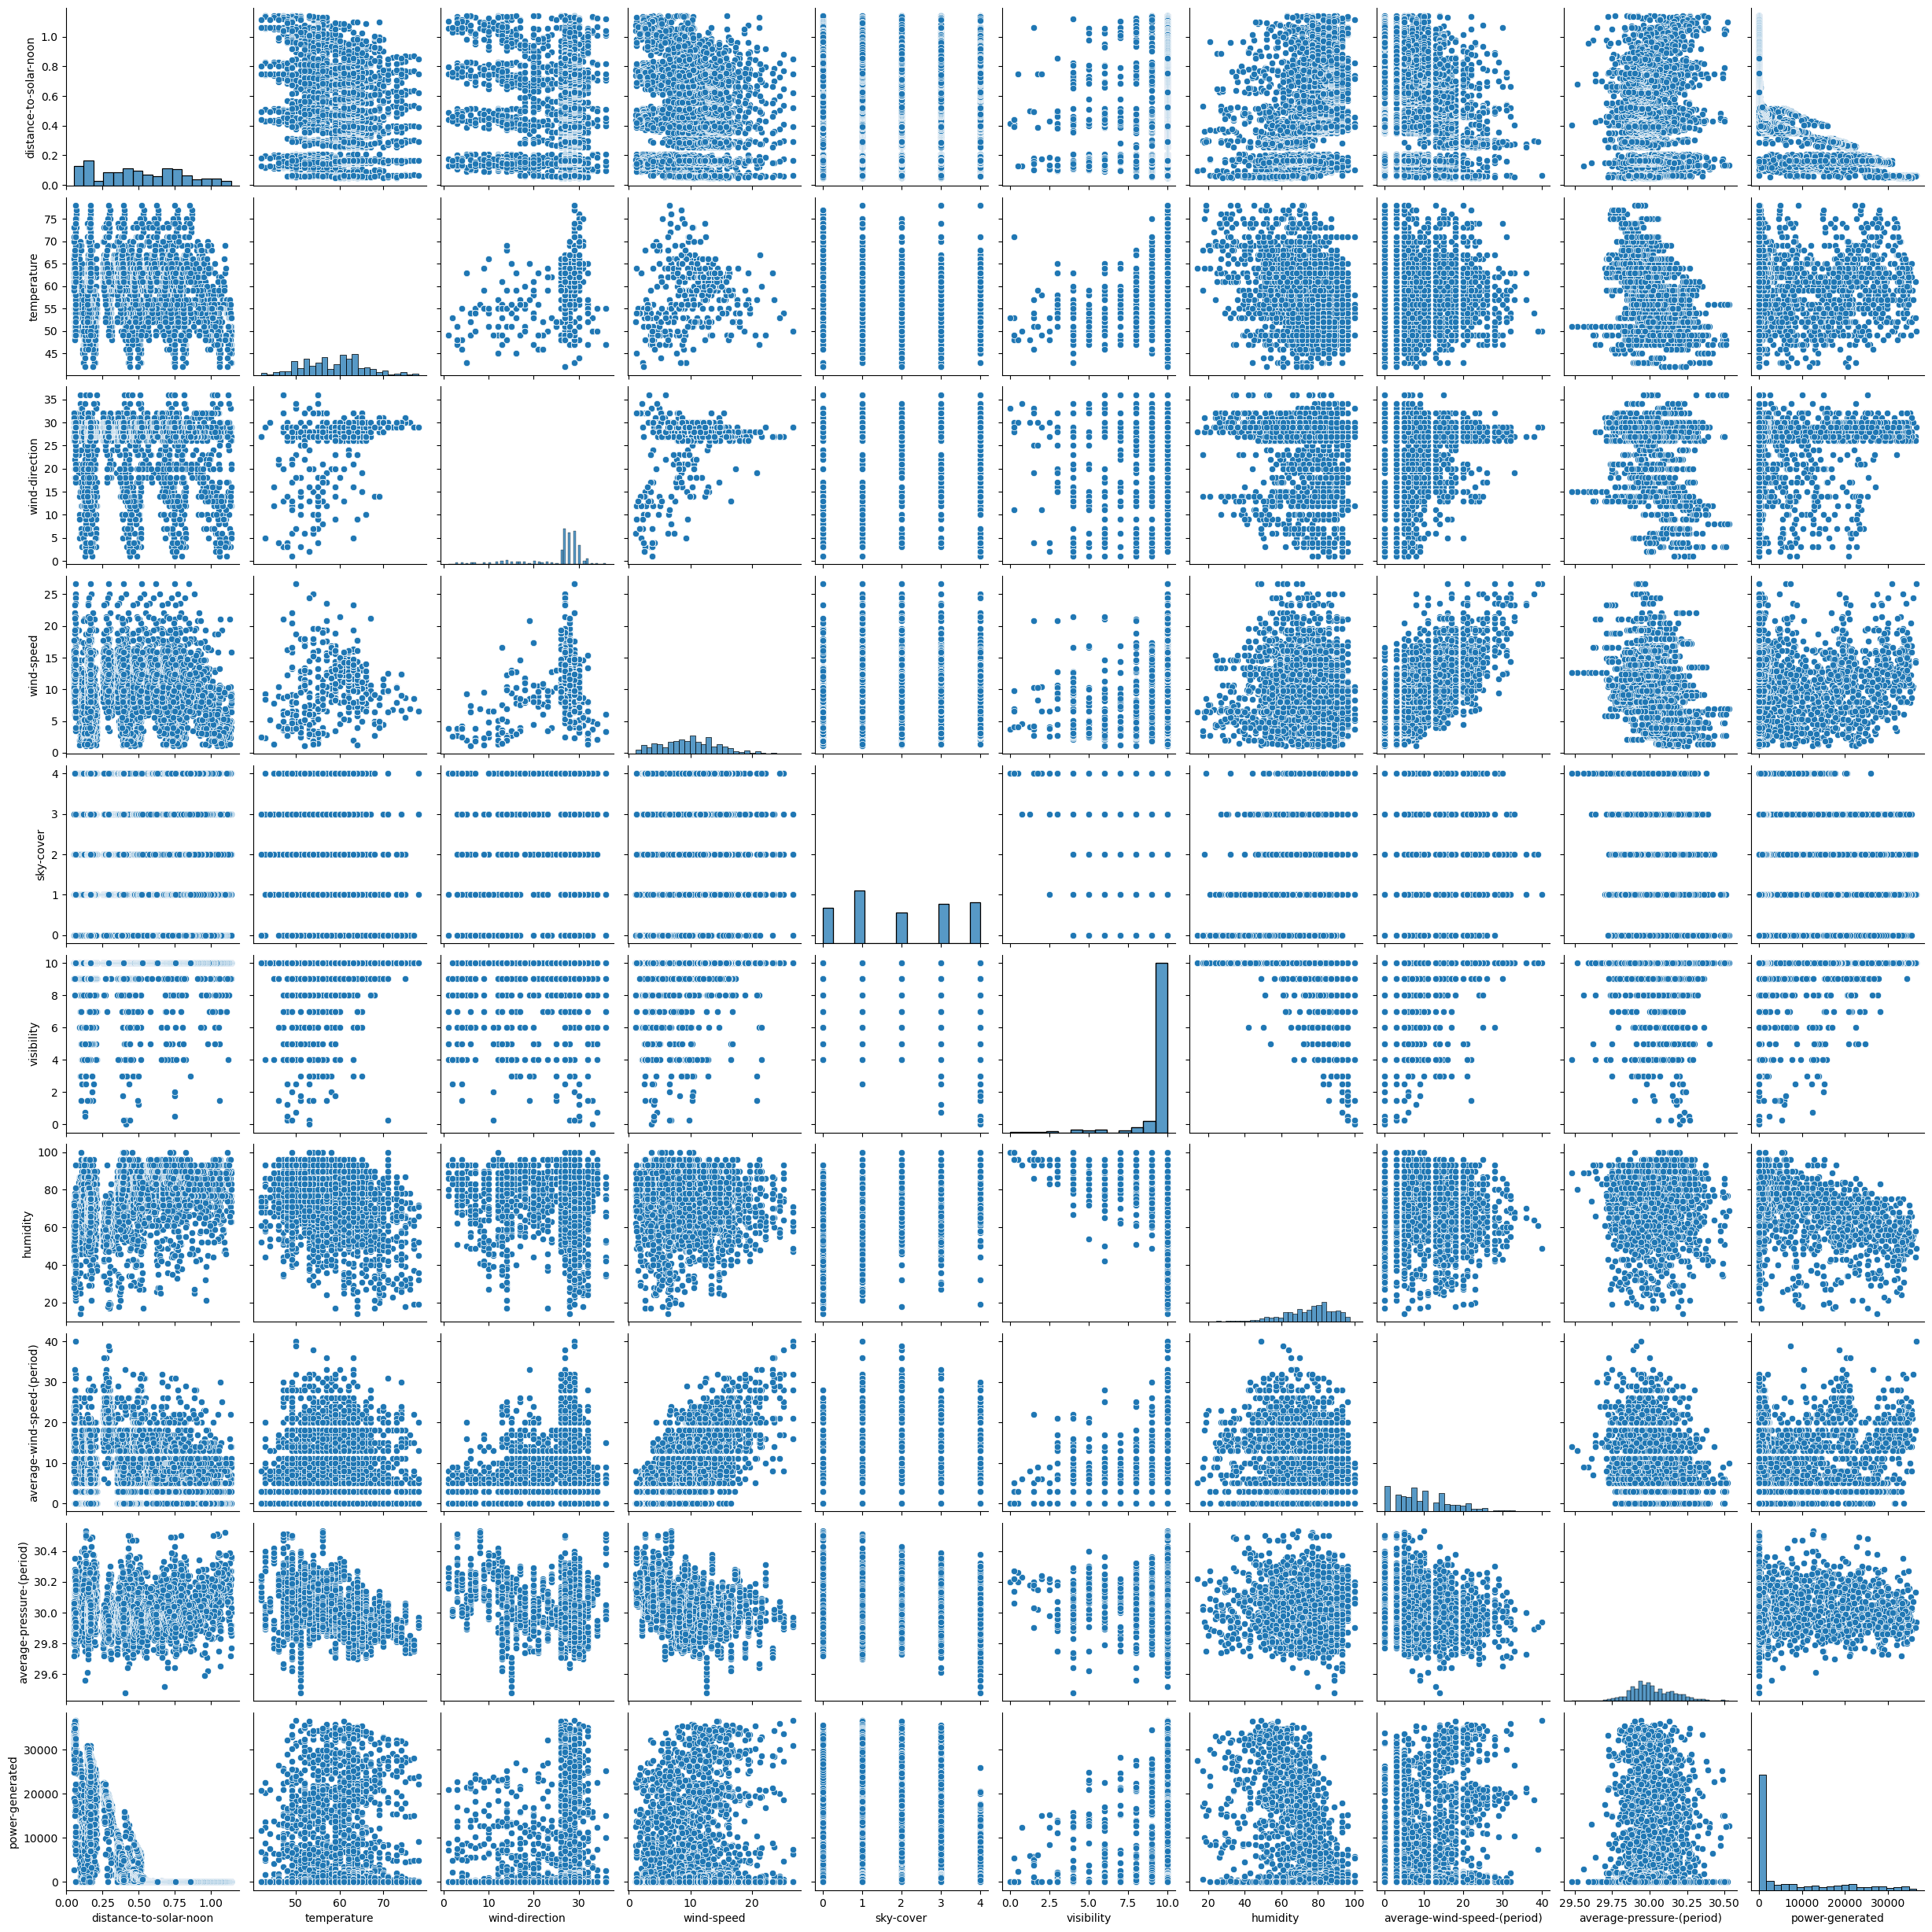

In [22]:
#Scatter plots between all features and target.
sns.pairplot(data)
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['features']= features.columns
vif['VIF_Scores']= [variance_inflation_factor(features.values,i) for i in range(len(features.columns))]
vif.sort_values(by='VIF_Scores',ascending=False)

,features,VIF_Scores
5,visibility,73405.212552
3,wind-speed,2.109412
7,average-wind-speed-(period),2.057511
6,humidity,1.575537
8,average-pressure-(period),1.508927
1,temperature,1.496228
4,sky-cover,1.388262
0,distance-to-solar-noon,1.251183
2,wind-direction,1.232470


In [24]:
from sklearn.feature_selection import f_regression

C:\Users\venka\anaconda3\manoj\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


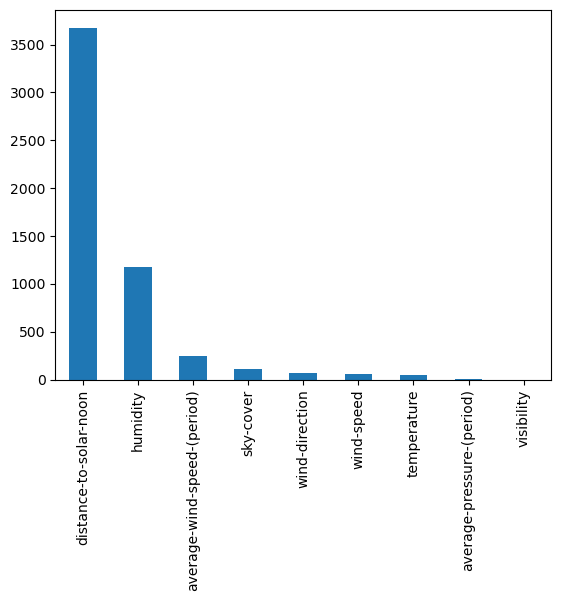

In [25]:
f_reg= f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [26]:
### here we found that the visibility , average_pressure(period), wind-speed , wind-direction have the lesss relation with the target column , so 
# remove the unwanted columns .

In [27]:
features1=features

In [28]:
features1.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period)
0,0.859897,69,28.0,7.5,0,10.0,75.0,8.0,29.82
1,0.628535,69,28.0,7.5,0,10.0,77.0,5.0,29.85
2,0.397172,69,28.0,7.5,0,10.0,70.0,0.0,29.89
3,0.165810,69,28.0,7.5,0,10.0,36.5,0.0,29.91
4,0.065553,69,28.0,7.5,0,10.0,36.5,3.0,29.89


In [29]:
features1.drop(columns=["visibility", "average-pressure-(period)", "wind-speed","wind-direction"], inplace=True)

In [30]:
features1.head()

,distance-to-solar-noon,temperature,sky-cover,humidity,average-wind-speed-(period)
0,0.859897,69,0,75.0,8.0
1,0.628535,69,0,77.0,5.0
2,0.397172,69,0,70.0,0.0
3,0.165810,69,0,36.5,0.0
4,0.065553,69,0,36.5,3.0


In [31]:
### here all the data is in standard format only , so we need not to transform the data 

In [32]:
# tarining the data and splitting the data into training and testing 

x_train,x_test, y_train,y_test=train_test_split(features1, target, test_size=0.2, random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2335, 5)
(584, 5)
(2335, 1)
(584, 1)


In [33]:
RM=LinearRegression()
RM.fit(x_train,y_train)


LinearRegression()

In [34]:
y_pred_train=RM.predict(x_train)
y_pred_train

array([[15675.66607174],
       [ 5017.27673118],
       [-1757.46228892],
       ...,
       [17924.73056152],
       [ 3032.10743309],
       [-1763.00316376]])

In [35]:
from sklearn.metrics import r2_score
r_score=r2_score(y_train,y_pred_train)
r_score

0.6535195725067282

In [36]:
y_pred_test=RM.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.6358367248544327

In [37]:
lasso=Lasso()
lasso.fit(x_train,y_train)

Lasso()

In [38]:
y_pred_train=lasso.predict(x_train)
r_score=r2_score(y_train,y_pred_train)
r_score

0.6535194330257821

In [39]:
y_pred_test=lasso.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.6358659674426694

In [40]:
ridge=Ridge()
ridge.fit(x_train,y_train)

Ridge()

In [41]:
y_pred_train=ridge.predict(x_train)
r_score=r2_score(y_train,y_pred_train)
r_score

0.65350732570718

In [42]:
y_pred_test=ridge.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.6361679045575193

In [43]:
enet=ElasticNet()
enet.fit(x_train,y_train)


ElasticNet()

In [44]:
y_pred_train=enet.predict(x_train)
r_score=r2_score(y_train,y_pred_train)
r_score

0.3906661492610657

In [45]:
y_pred_test=enet.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.4022218032999948

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost

In [47]:
random_forest=RandomForestRegressor(n_estimators=100, random_state=42,max_depth=6,max_features=5)
random_forest.fit(x_train,y_train)


C:\Users\venka\anaconda3\manoj\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=6, max_features=5, random_state=42)

In [48]:
y_pred_train=random_forest.predict(x_train)
r_score=r2_score(y_train,y_pred_train)
r_score

0.9217248590310942

In [49]:
y_pred_test=random_forest.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.9230486718732338

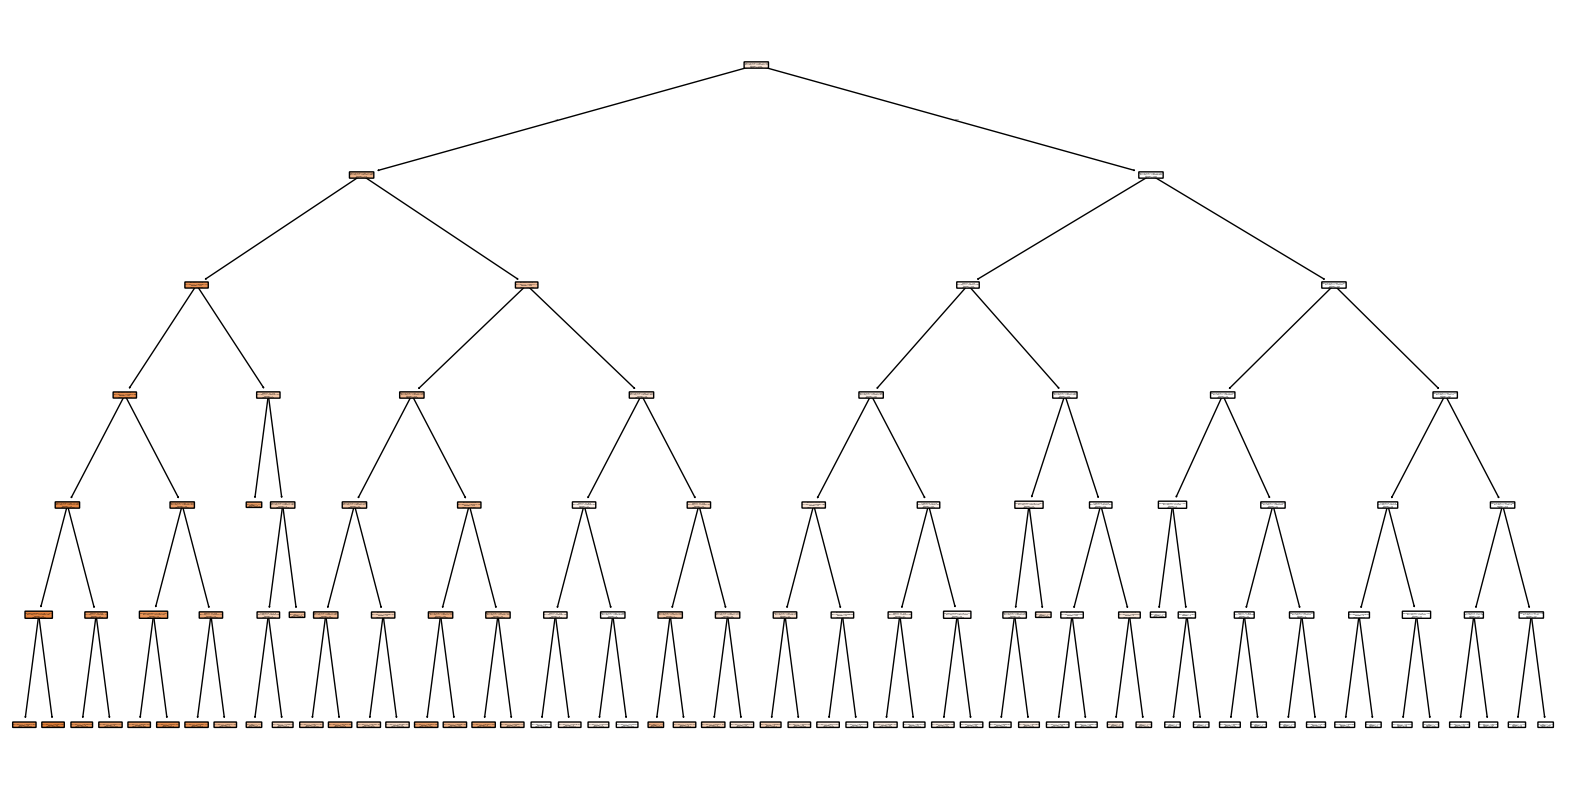

In [50]:
from sklearn.tree import plot_tree
# Plot one tree (example: first tree)
plt.figure(figsize=(20,10))
plot_tree(random_forest.estimators_[0],
          feature_names=features1.columns,
          filled=True,
          rounded=True)
plt.show()

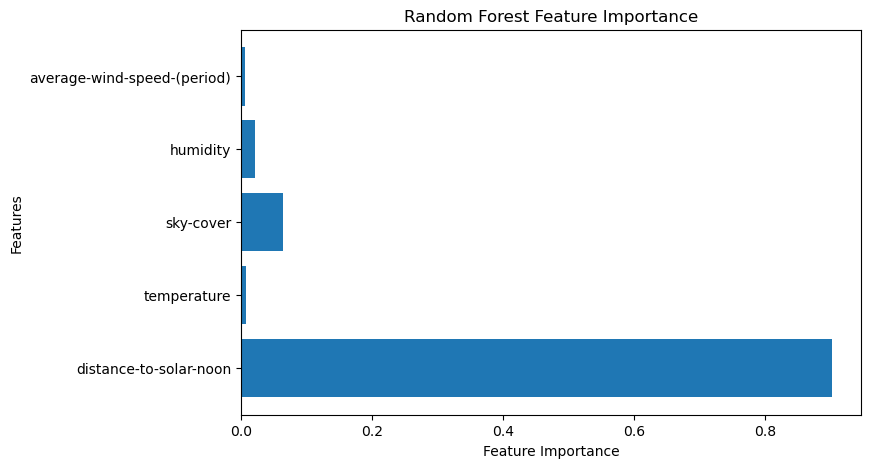

In [51]:
importances = random_forest.feature_importances_
features1 = features1.columns

plt.figure(figsize=(8,5))
plt.barh(features1, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

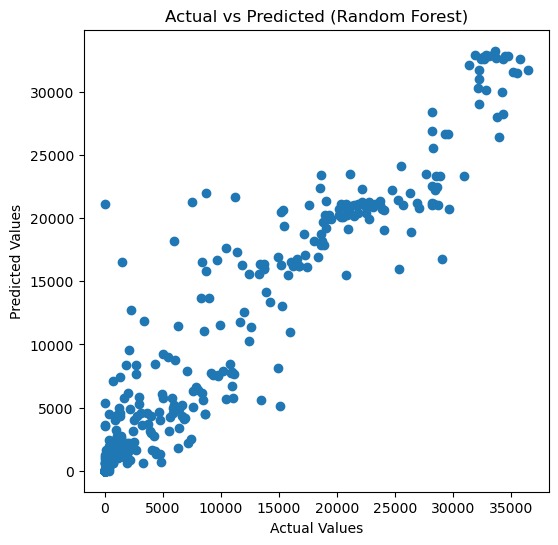

In [52]:
y_pred = random_forest.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [53]:
# residuals = y_test - y_pred_test

# plt.figure(figsize=(6,5))
# plt.scatter(y_pred, residuals)
# plt.axhline(0, linestyle="--")
# plt.xlabel("Predicted Values")
# plt.ylabel("Residuals")
# plt.title("Residual Plot")
# plt.show()

In [54]:
# x_range = np.linspace(features1.min(), features1.max(), 100).reshape(-1,1)
# y_range_pred = random_forest.predict(x_range)

# plt.scatter(features1, target, label="Data")
# plt.plot(x_range, y_range_pred, label="RF Prediction")
# plt.legend()
# plt.show()

In [55]:
! pip install graphviz

In [56]:

# from sklearn.tree import export_graphviz
# import graphviz

# dot_data = export_graphviz(
#     random_forest.estimators_[0],
#     feature_names=features1,
#     filled=True,
#     rounded=True
# )

# graph = graphviz.Source(dot_data)
# graph

In [57]:
dt=DecisionTreeRegressor(max_depth=4,max_features=10)
dt.fit(x_train,y_train)



DecisionTreeRegressor(max_depth=4, max_features=10)

In [58]:
y_pred_train=dt.predict(x_train)
r_score=r2_score(y_train,y_pred_train)
r_score

0.8759324318235675

In [59]:
y_pred_test=dt.predict(x_test)
r_score=r2_score(y_test,y_pred_test)
r_score

0.8934854434057777

In [60]:

### here we found that , the data is overfitting , so to solve that , we use the techniques like shufflesplit, standardshufflesplit etc.

In [61]:
import pickle
file="log_regression_project.pkl"

In [62]:
pickle.dump(random_forest,open(file,'wb'))